In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
#Task 1

# Load dataset
df = pd.read_csv("Hm10Data/Train.csv")

# Drop ID column
df = df.drop(columns=["id"])

# Separate features and target (we keep target aside)
target = df["term_deposit_subscribed"]
df = df.drop(columns=["term_deposit_subscribed"])

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# For missing values:
# Numeric -> median, Categorical -> most frequent
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Apply transformations
df_transformed = preprocessor.fit_transform(df)

# Convert back to DataFrame with column names
cat_features = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_cols)
all_features = numeric_cols + list(cat_features)
df_numeric = pd.DataFrame(df_transformed.toarray() if hasattr(df_transformed, "toarray") else df_transformed,
                          columns=all_features)

df_numeric.head()

,customer_age,balance,day_of_month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,job_type_admin.,job_type_blue-collar,job_type_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,prev_campaign_outcome_failure,prev_campaign_outcome_other,prev_campaign_outcome_success,prev_campaign_outcome_unknown
0,28.0,285.0,26.0,303.0,4.0,195.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,34.0,934.0,18.0,143.0,2.0,132.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,46.0,656.0,5.0,101.0,4.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,34.0,2.0,20.0,127.0,3.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,41.0,1352.0,13.0,49.0,2.0,195.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
#Task 2

# Initialize scaler
scaler = StandardScaler()

# Fit and transform the numeric dataframe
df_scaled = scaler.fit_transform(df_numeric)

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled.head()

,customer_age,balance,day_of_month,last_contact_duration,num_contacts_in_campaign,days_since_prev_campaign_contact,num_contacts_prev_campaign,job_type_admin.,job_type_blue-collar,job_type_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,prev_campaign_outcome_failure,prev_campaign_outcome_other,prev_campaign_outcome_success,prev_campaign_outcome_unknown
0,-1.165641,-0.349316,1.223313,0.186545,0.389492,-0.108850,-0.236683,-0.359782,-0.523923,-0.184059,...,2.729141,-0.103902,-0.664070,-0.311612,-0.127981,-0.115553,-0.351041,-0.204638,-0.187066,0.474406
1,-0.602124,-0.137742,0.262103,-0.440834,-0.245833,-1.352867,0.163376,-0.359782,1.908676,-0.184059,...,-0.366416,-0.103902,-0.664070,3.209122,-0.127981,-0.115553,-0.351041,4.886688,-0.187066,-2.107900
2,0.524910,-0.228370,-1.299864,-0.605521,0.389492,-0.108850,-0.236683,-0.359782,-0.523923,-0.184059,...,-0.366416,-0.103902,-0.664070,-0.311612,-0.127981,-0.115553,-0.351041,-0.204638,-0.187066,0.474406
3,-0.602124,-0.441573,0.502405,-0.503572,0.071830,-0.108850,-0.236683,-0.359782,-0.523923,-0.184059,...,-0.366416,-0.103902,1.505865,-0.311612,-0.127981,-0.115553,-0.351041,-0.204638,-0.187066,0.474406
4,0.055312,-0.001475,-0.338654,-0.809419,-0.245833,-0.108850,-0.236683,-0.359782,1.908676,-0.184059,...,-0.366416,-0.103902,1.505865,-0.311612,-0.127981,-0.115553,-0.351041,-0.204638,-0.187066,0.474406


In [4]:
#Task 3

from sklearn.utils import resample

# Sample the scaled dataset to speed up silhouette calculations
sample_df = resample(df_scaled, n_samples=5000, random_state=42)

gmm_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(sample_df)
    score = silhouette_score(sample_df, labels)
    gmm_scores.append(score)

best_k_gmm = cluster_range[np.argmax(gmm_scores)]

print("Best number of clusters for GMM:", best_k_gmm)
print("Silhouette scores for GMM:", gmm_scores)

Best number of clusters for GMM: 10
Silhouette scores for GMM: [np.float64(0.06069468245213034), np.float64(0.05712333990643665), np.float64(0.04974476487289259), np.float64(0.05459749136806954), np.float64(0.06220313768615063), np.float64(0.06650147004405671), np.float64(0.0722197177452802), np.float64(0.07441367011562657), np.float64(0.08001895979406415)]


In [5]:
#Task 4

kmeans_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sample_df)
    score = silhouette_score(sample_df, labels)
    kmeans_scores.append(score)

best_k_kmeans = cluster_range[np.argmax(kmeans_scores)]

print("Best number of clusters for KMeans:", best_k_kmeans)
print("Silhouette scores for KMeans:", kmeans_scores)

Best number of clusters for KMeans: 10
Silhouette scores for KMeans: [np.float64(0.04062246785873948), np.float64(0.05191288189631873), np.float64(0.05438912145189725), np.float64(0.061485720792645), np.float64(0.0723279699345196), np.float64(0.07337770563790846), np.float64(0.08214572969134028), np.float64(0.0707803693468363), np.float64(0.09131568067372903)]


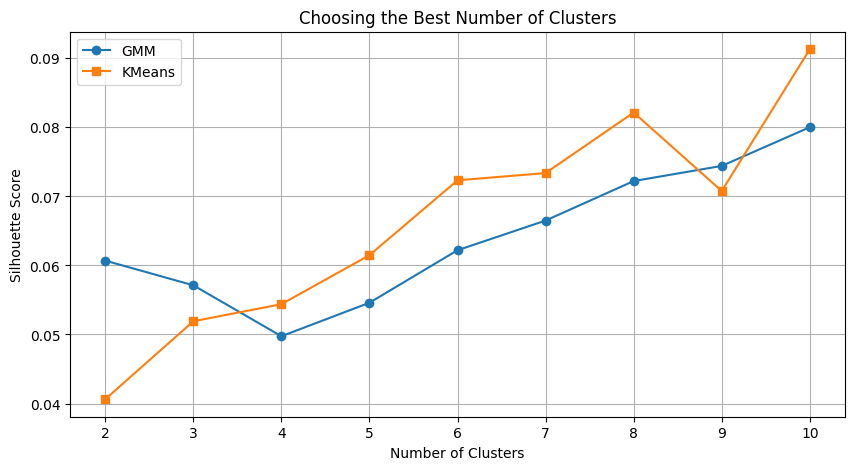

In [6]:
#Task 5

plt.figure(figsize=(10, 5))

# Plot GMM scores
plt.plot(cluster_range, gmm_scores, marker="o", label="GMM")

# Plot KMeans scores
plt.plot(cluster_range, kmeans_scores, marker="s", label="KMeans")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Choosing the Best Number of Clusters")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
#Task 6
# Final GMM model
gmm_final = GaussianMixture(n_components=best_k_gmm, random_state=42)
gmm_labels = gmm_final.fit_predict(df_scaled)

# Final KMeans model
kmeans_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(df_scaled)

# Store labels for later
df_clusters = df_scaled.copy()
df_clusters["GMM_Cluster"] = gmm_labels
df_clusters["KMeans_Cluster"] = kmeans_labels

In [8]:
#Task 7
kmeans_centroids = kmeans_final.cluster_centers_
kmeans_centroids_df = pd.DataFrame(kmeans_centroids, columns=df_scaled.columns)
print(kmeans_centroids_df)

   customer_age   balance  day_of_month  last_contact_duration  \
0     -1.331456  0.009717     -0.091080              -0.048354   
1     -0.117259 -0.054601     -0.294441              -0.041111   
2     -0.163574 -0.121148      0.056943               0.020206   
3     -0.159700 -0.484561      0.061344              -0.077801   
4      0.419874  0.223340     -0.135354               0.210756   
5      0.109070  0.419644      0.326796              -0.014827   
6     -0.011153 -0.130919      0.339706               0.061287   
7      0.122814  0.091717     -0.553249              -0.067162   
8      0.135536  0.048433     -0.022175              -0.052266   
9      0.510924  0.028487      0.027443              -0.067766   

   num_contacts_in_campaign  days_since_prev_campaign_contact  \
0                 -0.154523                         -0.131584   
1                 -0.191489                          1.541103   
2                 -0.090747                         -0.108850   
3            

In [9]:
#Task 8
gmm_means = gmm_final.means_
gmm_means_df = pd.DataFrame(gmm_means, columns=df_scaled.columns)
print(gmm_means_df)

   customer_age   balance  day_of_month  last_contact_duration  \
0     -0.129713 -0.044495      0.065367               0.100309   
1     -0.157461 -0.225467      0.032994               0.017991   
2     -0.238850 -0.013268     -0.162912              -0.009598   
3      1.907255  0.202425     -0.057193               0.097284   
4      0.396187  0.106744      0.229277              -0.145951   
5      0.100277  0.018847      0.109404              -0.095775   
6     -0.476898  0.128970     -0.127837               0.093590   
7     -0.212294  0.046046      0.099154               0.013336   
8     -0.056967 -0.043679     -0.057082              -0.012986   
9     -0.097266  0.008815     -0.206408              -0.059824   

   num_contacts_in_campaign  days_since_prev_campaign_contact  \
0                 -0.083228                         -0.108850   
1                  0.018491                         -0.108850   
2                 -0.100422                          0.619690   
3            

In [10]:
# Task 9 - Build comparison table for both algorithms

from sklearn.metrics import silhouette_samples
import numpy as np

# Prepare a helper function to build the table
def build_cluster_table(model_name, labels, centers, data):
    # Count samples in each cluster
    cluster_ids = np.unique(labels)
    counts = np.bincount(labels)

    # Silhouette scores per sample
    sil_samples = silhouette_samples(data, labels)

    # Build rows
    rows = []
    for cid in cluster_ids:
        cluster_sil = np.mean(sil_samples[labels == cid])
        rows.append({
            "Algorithm": model_name,
            "Cluster": cid,
            "Num_Samples": counts[cid],
            "Silhouette_Mean": cluster_sil,
            "Center/Mean": centers[cid]  # array of feature values
        })
    return rows

# Build tables for KMeans and GMM
kmeans_table = build_cluster_table("KMeans", kmeans_labels, kmeans_final.cluster_centers_, df_scaled)
gmm_table = build_cluster_table("GMM", gmm_labels, gmm_final.means_, df_scaled)

# Combine into one DataFrame
comparison_df = pd.DataFrame(kmeans_table + gmm_table)

# Optional: format the center/mean array into shorter strings for display
comparison_df["Center/Mean"] = comparison_df["Center/Mean"].apply(lambda arr: np.round(arr, 3))

comparison_df


,Algorithm,Cluster,Num_Samples,Silhouette_Mean,Center/Mean
0,KMeans,0,661,0.190211,"[-1.331, 0.01, -0.091, -0.048, -0.155, -0.132,..."
1,KMeans,1,3291,0.006271,"[-0.117, -0.055, -0.294, -0.041, -0.191, 1.541..."
2,KMeans,2,7378,0.177813,"[-0.164, -0.121, 0.057, 0.02, -0.091, -0.109, ..."
3,KMeans,3,553,0.346865,"[-0.16, -0.485, 0.061, -0.078, 0.112, -0.003, ..."
4,KMeans,4,1656,-0.081715,"[0.42, 0.223, -0.135, 0.211, -0.316, -0.587, 0..."
5,KMeans,5,2563,0.112665,"[0.109, 0.42, 0.327, -0.015, -0.28, -0.343, 0...."
6,KMeans,6,5501,0.049258,"[-0.011, -0.131, 0.34, 0.061, 0.144, -0.118, -..."
7,KMeans,7,3253,0.093601,"[0.123, 0.092, -0.553, -0.067, 0.162, -0.139, ..."
8,KMeans,8,5918,0.053817,"[0.136, 0.048, -0.022, -0.052, 0.21, -0.189, -..."
9,KMeans,9,873,0.199310,"[0.511, 0.028, 0.027, -0.068, 0.016, -0.127, -..."


# Task 10: Conclusion

Both KMeans and GMM found 10 clusters, but their quality varies.

Most silhouette scores are low (close to 0), which means the clusters are not perfectly separated, so the groups overlap a lot.

The highest silhouette score for KMeans is about 0.35 (Cluster 3, 553 customers), this is the clearest and most distinct customer group.

Some clusters have negative silhouette scores (e.g., KMeans cluster 4, GMM cluster 6), meaning some customers in these groups may fit better in another cluster.

A few clusters are much larger (over 7,000 customers) — these represent common customer profiles. Others are small (under 700), these are niche or special-case customers.

In plain words:
Customers can be grouped into several profiles, but many profiles are quite similar to each other. Only a couple of groups stand out as truly unique, while others are mixed and overlap, so the boundaries aren’t crystal clear :D